# GHG ↔ ODIAC + OCO-2/OCO-3 validation — analysis notebook

Steps D + F of the validation brief. **Activity validation** (Part A) compares the GHG pillar's raw inputs (CH₄ anomaly z, CH₄ raw concentration, VIIRS) against ODIAC fossil-CO₂ emissions; **concentration validation** (Part B) compares them against OCO-2/OCO-3 XCO₂ atmospheric retrievals.

Run `analysis/extract_part_a.py` and `analysis/extract_part_b.py` first to build `analysis/ghg_odiac_validation.csv`. ODIAC is sampled via Earth Engine; OCO XCO₂ is **not** in EE and is sourced via `earthaccess` from NASA GES DISC. N=25, operator-picked — findings are illustrative, not statistically conclusive. See `docs/ghg_odiac_validation.md`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline
import pandas as pd
from IPython.display import Image, display
from analysis import analysis_plots as ap
df = ap.load()
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
df

,regime,location,lat,lon,radius_km,ch4_z,ch4_site_ppb,ch4_background_ppb,ch4_anomaly_ppb,ch4_confidence,ch4_score,viirs_site,viirs_z,viirs_score,odiac_aoi_mean_tco2,odiac_total_tco2,odiac_relative_intensity,odiac_point_tco2,ghg_composite,ghg_activity_score,partA_flags,xco2_mean,xco2_std,xco2_count,xco2_n_oco2,xco2_n_oco3,xco2_n_granules,xco2_bg_mean,xco2_bg_count,xco2_delta,partB_flags
0,Urban,London,51.5074,-0.1278,5.0,-0.399554,1893.749991,1896.735926,-2.985936,0.338357,0.000000,85.859951,3.345772,1.000000,7936.021173,9.912557e+05,2.158129,8.348844e+03,1.000000,1.000000,NaN,425.303619,2.383926,669,172,497,12,423.778778,3341,1.524841,NaN
1,Urban,Mexico City,19.4326,-99.1332,5.0,0.001296,1946.810133,1946.797665,0.012468,0.344441,0.000432,128.295272,1.490675,0.496892,26298.450170,2.168333e+06,1.904234,7.566043e+04,0.496892,0.496892,NaN,424.928467,1.674585,3502,2324,1178,12,425.493164,4222,-0.564697,NaN
2,Urban,Mumbai,19.0760,72.8777,5.0,1.325626,1977.204395,1964.731840,12.472555,0.442145,0.441875,69.074960,1.921112,0.640371,35081.757512,2.885647e+06,2.300069,4.041283e+04,0.640371,0.640371,NaN,425.089447,1.613806,46,30,16,3,423.211792,87,1.877655,NaN
3,Urban,Lagos,6.5244,3.3792,5.0,NaN,NaN,NaN,NaN,NaN,NaN,24.252485,0.857045,0.285682,6948.515642,5.434557e+05,2.502287,7.349422e+03,0.285682,0.285682,ch4_fail:SiteBufferNoDataError,422.876953,2.143048,50,20,30,4,422.776917,274,0.100037,NaN
4,Urban,Seoul,37.5665,126.9780,5.0,0.407299,1947.604435,1944.253381,3.351054,0.360215,0.135766,78.869281,1.527751,0.509250,66796.936708,6.552387e+06,2.764594,6.332319e+04,0.509250,0.509250,NaN,423.866852,2.857253,3661,3406,255,10,425.395203,1405,-1.528351,NaN
5,Oil/Gas,Permian Basin,31.9000,-102.1000,5.0,-0.792776,1931.975456,1934.560031,-2.584576,0.574129,0.000000,28.647667,0.607519,0.202506,132.595948,1.214319e+04,0.092246,1.042084e+02,0.202506,0.202506,NaN,425.381744,1.229998,713,372,341,8,425.155884,6944,0.225861,NaN
6,Oil/Gas,Bakken,47.8000,-103.0000,5.0,0.524293,1898.583349,1896.563235,2.020115,0.549468,0.174764,9.821787,0.254575,0.084858,274.267195,3.174078e+04,0.791524,3.196552e+02,0.084858,0.084858,NaN,424.014038,1.201845,226,0,226,5,424.266541,3599,-0.252502,NaN
7,Oil/Gas,Hassi Messaoud,31.6800,6.0700,5.0,-4.031930,1917.996642,1933.567938,-15.571296,0.511448,0.000000,228.833016,1.175687,0.391896,4673.332634,4.270143e+05,8.626287,1.168462e+04,0.391896,0.391896,NaN,423.184509,1.412443,16,16,0,2,424.155975,2212,-0.971466,NaN
8,Oil/Gas,Tengiz,46.1300,53.5000,5.0,0.702420,1938.307249,1936.188040,2.119209,0.574160,0.234140,6.013494,0.245345,0.081782,652.897016,7.322688e+04,0.746679,5.257404e+02,0.081782,0.081782,NaN,421.523376,2.982483,759,219,540,11,422.307037,5813,-0.783661,NaN
9,Oil/Gas,Comodoro,-45.8645,-67.4969,5.0,-2.524171,1827.797104,1847.131359,-19.334256,0.372579,0.000000,44.088805,3.318475,1.000000,8242.534392,9.203194e+05,10.000000,1.834373e+05,1.000000,1.000000,NaN,423.752686,0.559134,301,301,0,3,423.730438,4651,0.022247,NaN


## Part A — activity validation (vs ODIAC)

ODIAC uses its 2023 vintage; CH₄/VIIRS use the 2025-06→2025-12 window (temporal-aggregation mismatch — see report §7). Plots saved to `analysis/plots/`.

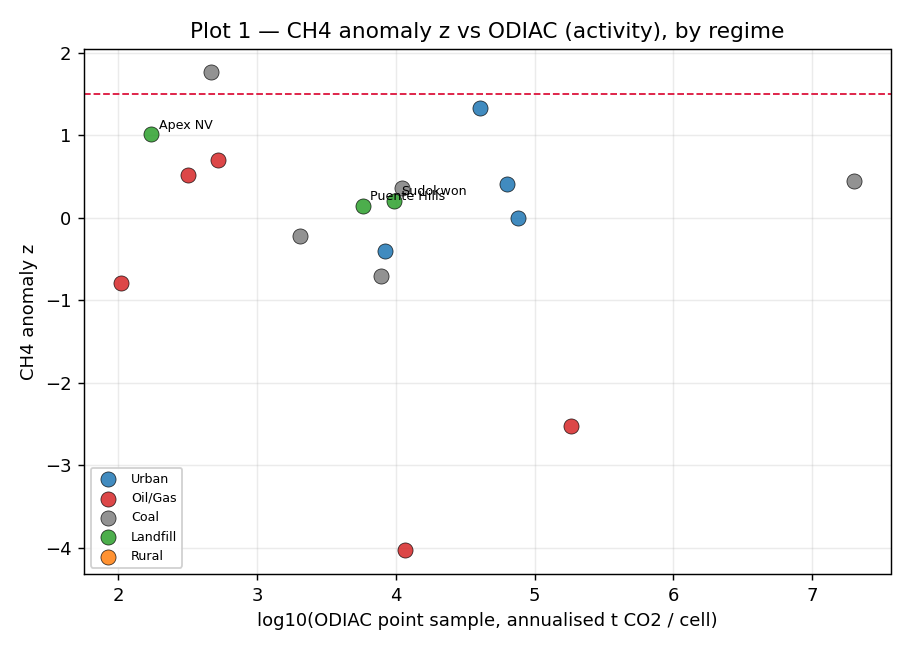

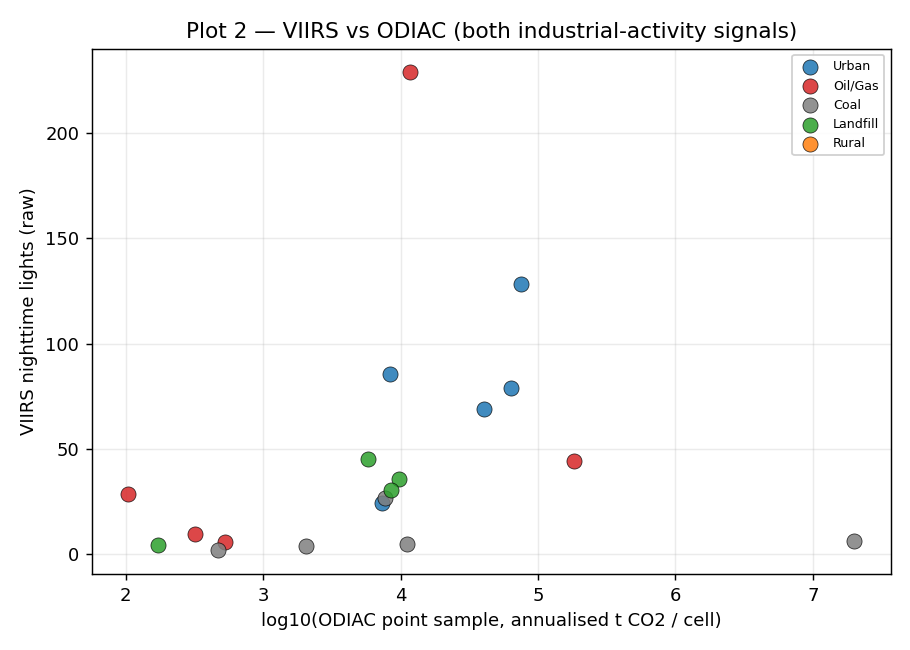

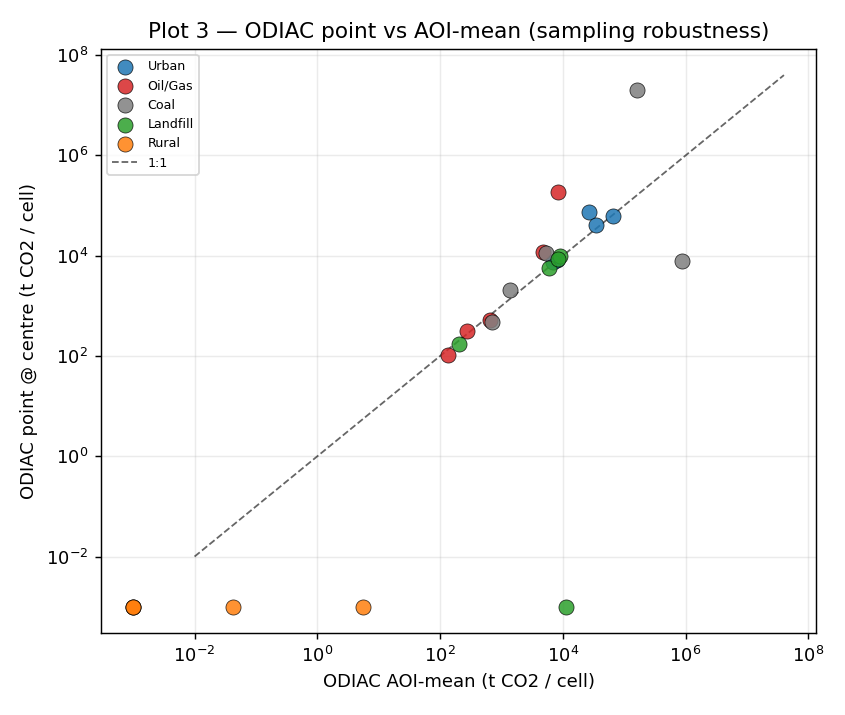

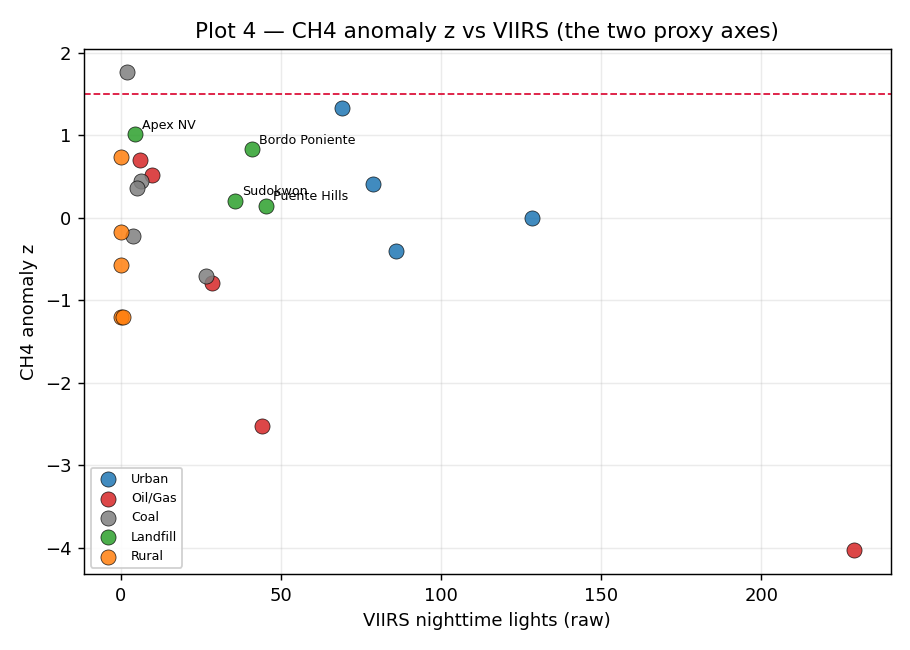

In [2]:
ap.part_a_plots(df)
for p in ['plot1_ch4z_vs_odiac','plot2_viirs_vs_odiac',
          'plot3_odiac_point_vs_mean','plot4_ch4z_vs_viirs']:
    display(Image(filename=f'plots/{p}.png'))

In [3]:
print(ap.corr_tables(df))
print(ap.divergence(df))


### Part A — activity (vs ODIAC point, log10)

| regime | CH4–ODIAC Pearson | CH4–ODIAC Spearman | n | VIIRS–ODIAC Pearson | VIIRS–ODIAC Spearman | n |
|---|---|---|---|---|---|---|
| Urban | 0.44 | 0.2 | 4 | 0.66 | 0.7 | 5 |
| Oil/Gas | -0.72 | -0.5 | 5 | 0.42 | 0.5 | 5 |
| Coal | -0.15 | -0.1 | 5 | 0.03 | 0.7 | 5 |
| Landfill | -0.63 | -0.6 | 4 | -0.12 | -0.1 | 5 |
| Rural | None | None | 5 | None | None | 5 |
| ALL | -0.0 | -0.01 | 23 | 0.38 | 0.7 | 25 |

### Part B — concentration (vs XCO2 delta)

| regime | VIIRS–XCO2 Pearson | VIIRS–XCO2 Spearman | n | CH4–XCO2 Pearson | CH4–XCO2 Spearman | n |
|---|---|---|---|---|---|---|
| Urban | -0.18 | -0.3 | 5 | -0.1 | 0.2 | 4 |
| Oil/Gas | -0.57 | -0.1 | 5 | -0.4 | -0.2 | 5 |
| Coal | 0.74 | 1.0 | 5 | 0.71 | 0.8 | 5 |
| Landfill | 0.32 | 0.2 | 5 | 0.1 | -0.4 | 4 |
| Rural | 0.29 | 0.4 | 4 | -0.95 | -0.8 | 4 |
| ALL | -0.17 | -0.0 | 24 | -0.06 | -0.12 | 22 |

### Divergence cases (CH4 anomaly z firing, threshold z>1.5)

- **Urban** — fire

## Part B — concentration validation (vs OCO XCO₂)

XCO₂ delta = AOI-box (±0.25° ≈ 25 km) mean − local-background (0.25°–1.0° annulus) mean, pooled over the window from good-quality OCO-2 + OCO-3 soundings. Sparse-coverage locations (no delta) are excluded from the scatters; coverage varies by regime — rural/landfill are sparsest.

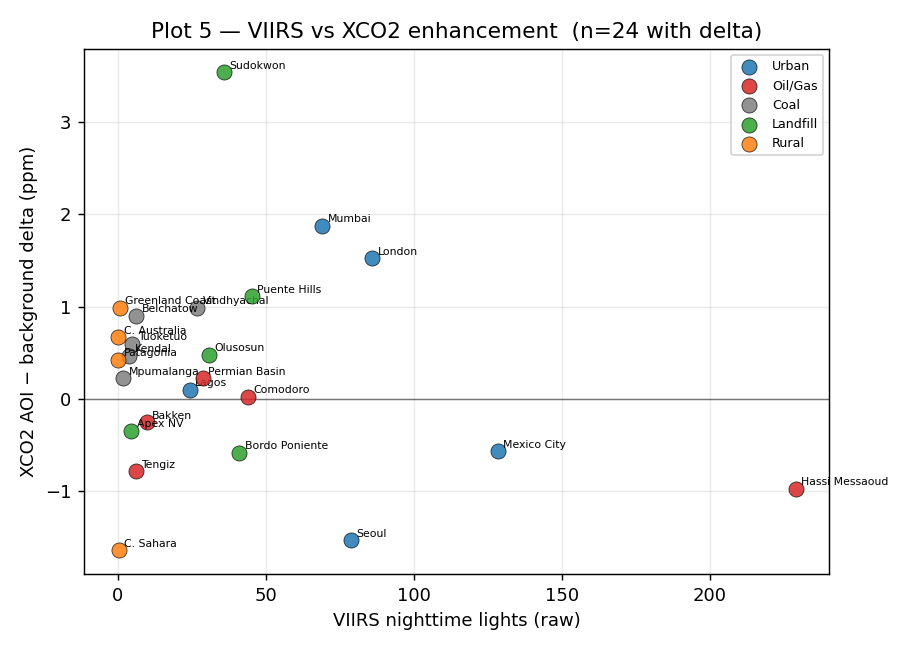

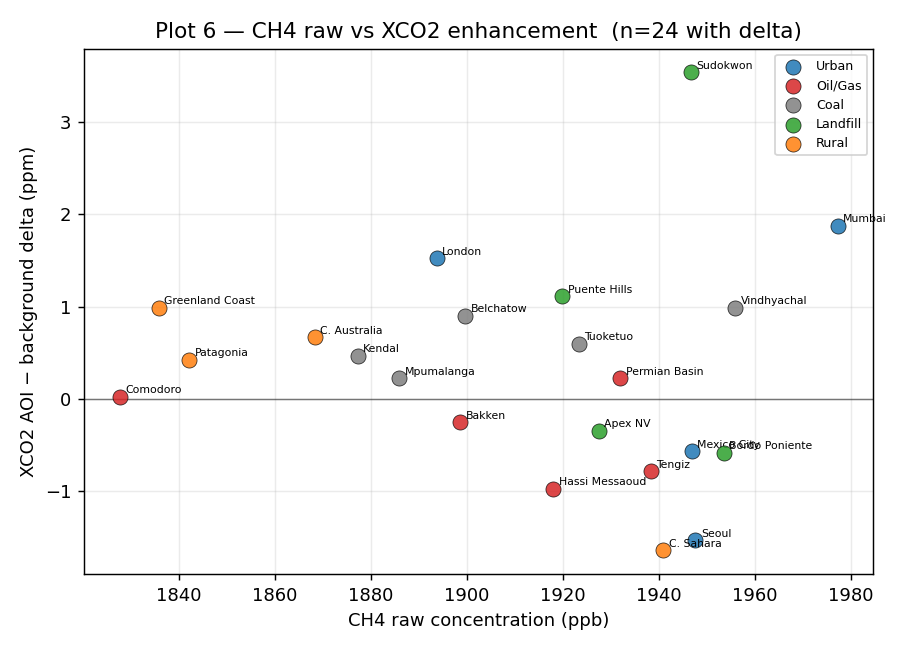

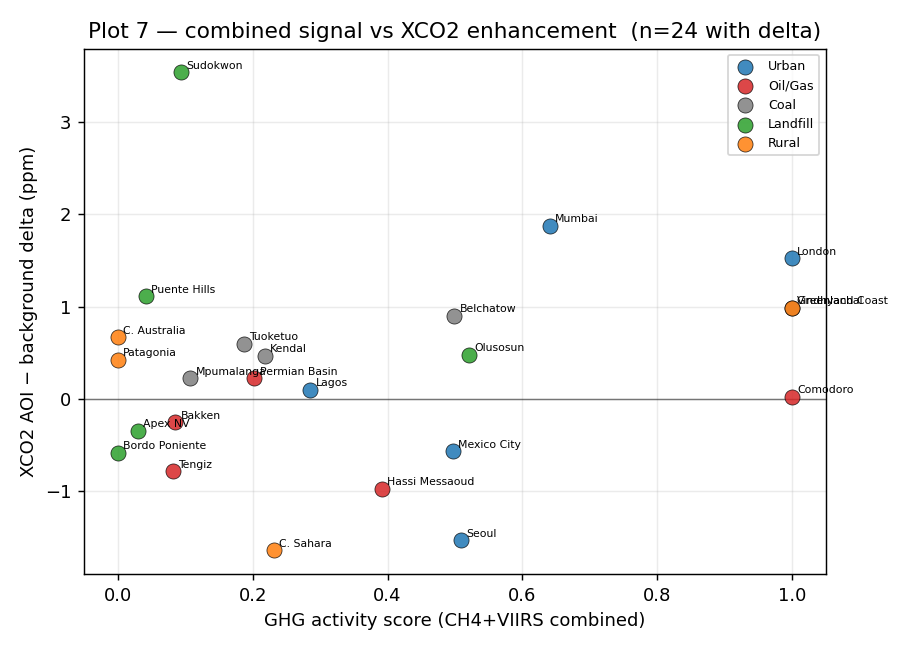

In [4]:
ap.part_b_plots(df)
for p in ['plot5_viirs_vs_xco2','plot6_ch4_vs_xco2','plot7_combined_vs_xco2']:
    display(Image(filename=f'plots/{p}.png'))

In [5]:
cov = df[['regime','location','xco2_count','xco2_n_oco2','xco2_n_oco3',
          'xco2_bg_count','xco2_delta','partB_flags']]
cov

,regime,location,xco2_count,xco2_n_oco2,xco2_n_oco3,xco2_bg_count,xco2_delta,partB_flags
0,Urban,London,669,172,497,3341,1.524841,NaN
1,Urban,Mexico City,3502,2324,1178,4222,-0.564697,NaN
2,Urban,Mumbai,46,30,16,87,1.877655,NaN
3,Urban,Lagos,50,20,30,274,0.100037,NaN
4,Urban,Seoul,3661,3406,255,1405,-1.528351,NaN
5,Oil/Gas,Permian Basin,713,372,341,6944,0.225861,NaN
6,Oil/Gas,Bakken,226,0,226,3599,-0.252502,NaN
7,Oil/Gas,Hassi Messaoud,16,16,0,2212,-0.971466,NaN
8,Oil/Gas,Tengiz,759,219,540,5813,-0.783661,NaN
9,Oil/Gas,Comodoro,301,301,0,4651,0.022247,NaN


## Caveats

- **N=25, operator-picked** — illustrative, not statistically conclusive.
- **ODIAC is monthly bottom-up inventory** (2020–2023), not observation; the GHG pillar is window-based and current — a temporal-aggregation mismatch.
- **OCO coverage varies by location** — sparse-evidence findings are weaker; rural/landfill regimes have fewer retrievals than urban/point sources.
- **Atmospheric transport decouples local sources from local concentration peaks** — the wind-attributability story applies to XCO₂ as it did to air quality (M-WIND-A1).
- **ODIAC and OCO measure different things** (emissions allocation vs column concentration) — two complementary benchmarks, each one form of evidence.

## §10 — Response B: AOI widening (5 km → 15 km)

Tests whether widening the CH₄ AOI beyond TROPOMI's ~7 km footprint restores the anomaly-z signal. Re-extraction at 15 km is in `ghg_odiac_validation_widened_aoi.csv` (run `extract_ch4_widened.py` first). **Verdict: No** — firing went 1/25 → 0/25; widening dilutes the sub-pixel plume faster than it separates site from background. See report §10.

# Response B — 5 km vs 15 km AOI comparison


## Side-by-side CH4 anomaly z

| regime | location | z @5km | z @15km | Δ |
|---|---|---|---|---|
| Urban | London | -0.40 | +0.90 | +1.30 |
| Urban | Mexico City | +0.00 | +1.34 | +1.34 |
| Urban | Mumbai | +1.33 | +0.66 | -0.67 |
| Urban | Lagos | n/a | +0.87 | n/a |
| Urban | Seoul | +0.41 | +0.65 | +0.24 |
| Oil/Gas | Permian Basin | -0.79 | +0.15 | +0.94 |
| Oil/Gas | Bakken | +0.52 | -0.05 | -0.58 |
| Oil/Gas | Hassi Messaoud | -4.03 | -2.75 | +1.29 |
| Oil/Gas | Tengiz | +0.70 | +0.46 | -0.25 |
| Oil/Gas | Comodoro | -2.52 | -4.09 | -1.57 |
| Coal | Belchatow | +0.45 | +0.19 | -0.26 |
| Coal | Tuoketuo | +0.36 | +0.30 | -0.06 |
| Coal | Vindhyachal | -0.71 | -0.25 | +0.46 |
| Coal | Mpumalanga | +1.76 | +0.79 | -0.97 |
| Coal | Kendal | -0.22 | +0.32 | +0.54 |
| Landfill | Sudokwon | +0.21 | +0.75 | +0.55 |
| Landfill | Bordo Poniente | +0.83 | +1.46 | +0.63 |
| Landfill | Apex NV | +1.01 | +0.52 | -0.49 |
| Landfill | Puente Hills |

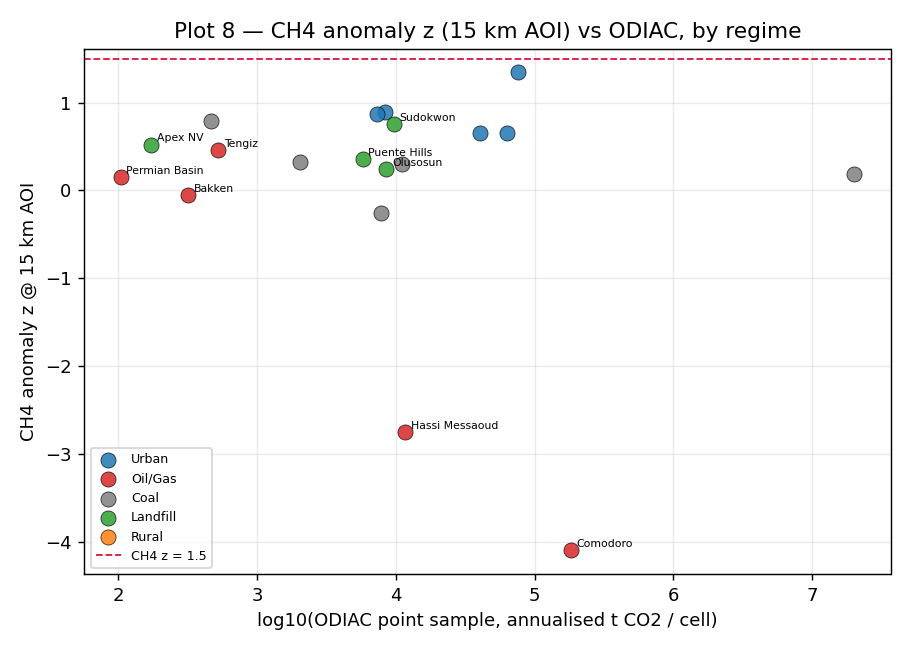

In [6]:
from analysis import response_b_compare as rb
rb.main()
display(Image(filename='plots/plot8_ch4z15_vs_odiac.png'))